# Project Final Report

### Due: Midnight on April 27th (2-hour grace period) — 50 points  

### No late submissions will be accepted.


## Overview

Your final submission consists of **two components**:


### 1. Team Final Report Notebook [50 pts]

Complete all sections of this notebook to document your final decisions, results, and broader context.

You will write a **technical report** following standard conventions. Useful references include:
- [CMU guide to structure](https://www.stat.cmu.edu/~brian/701/notes/paper-structure.pdf)
- [Data science report example](https://www.projectpro.io/article/data-science-project-report/620)
- The Checklist in this week’s Blackboard Lesson (aligned with HOML)

Your audience is **technically literate but unfamiliar with your work**—for example, your manager or other data scientists. Your report should be clear, precise, and well-organized, combining explanation, visualizations, and interpretation.

This Final Report is distinct from Milestone 2:

- **Milestone 2** serves as a repository of your working code and experiments  
- **This Final Report** presents a clear, structured summary of your project for a professional audience  

> **Important:**
> - Do **not** assume that readers of this report are familiar with Milestone 2. Your report should stand on its own.
> - Do not include full code or code cells in this notebook. All code was submitted in Milestone 2. This report should focus on explanation, results, and interpretation.
> - **Do not add, delete, or move cells in this notebook.** Each answer must be written entirely within its assigned Markdown cell.
> - All answers should be inserted directly under the appropriate `Answer:` prompt. Delete the sentence "Replace this sentence with your answer" and replace it with your response.
> - You may use any appropriate Markdown formatting (paragraphs, lists, tables, inserted graphics, LaTeX, etc.).
> - Submit this notebook as a group via your team leader’s Gradescope account.


### 2. Individual Assessment [0 points]

Each team member must **individually** complete the Final Project Individual Assessment Form (similar to Milestone 1), sign it, and upload it via their own Gradescope account.

**Due:** May 5th @ 2:00 AM



## Submission Checklist

- Final Report Notebook — submitted by team leader  
- Individual Assessment Form — submitted by each team member  



## 1. Executive Summary [4 pts]

Write a 300–400 word executive summary for a **non-technical audience**, such as business stakeholders in a real estate company.

Your summary should explain:
- the objective of the project
- key insights about the data
- the most important findings, including a plain-language description of model performance
- a clear recommendation or takeaway

Avoid technical detail and jargon. Focus on what matters and why. 

**1.1 Answer:**  
Replace this sentence with your answer. 

## 2. Introduction [3 pts]

Introduce the topic, context, and goals of your project.

You may imagine that this project was completed for a **real estate company with a small in-house data science team**.

Include all of the following:

- Clearly introduce the topic and context of your project
- Describe the problem you are addressing (the problem statement) and the overall motivation for solving it
- Clearly state the objectives and goals of your analysis (as different from the motivation)

**2.1 Answer:**  

Topic Introduction:
This project was carried out in the context of a real estate company, operating with in-house data scientists. The company is seeking to better understand factors that influence or drive property values (tax value in this instance) so that they can develop an automated tool that estimates values quickly and reliably at scale. 

The job of estimating property values has historically been done through manual appraisals, carried out by licensed individuals, an activity that is time-consuming, costly, and can be inconsistent across different appraisers. With the growth in the real estate market and the need for numerous appraisals and more immediate valuations, the limitations of manual appraisals become apparent. Automated real estate valuation models offer the potential to deliver faster, more consistent estimates at scale, supporting a wide range of customer needs and applications, from mortgage underwriting, to market analysis to consumer-facing valuation tools such as property websites like Zillow.

The Problem:
The main problem addressed by this project is: given a set of observable and reportable characteristics of a residential property, can we build a machine learning model that accurately predicts its assessed tax value? This is being approached as a supervised regression problem, with the target variable being taxvaluedollarcnt, defined as the total assessed value of the property in U.S. dollars. The dataset includes properties from three California counties, making the model relevant for regional real estate valuation in those areas.

The dataset used in this project is derived from the Zillow Prize competition hosted on Kaggle in 2017. It mirrors the challenges encountered in a real-world data exercise, including substantial missing values, correlated features, outliers, and a wide distribution of property values.

Objectives and Goals:
The objectives of this analysis are distinct from the broader motivation described above. Specifically, the goals of this project were:
* To determine which property characteristics are the strongest drivers of tax assessed home value in the Southern California market.
* To establish how accurately a machine learning model can predict residential property tax values from available features, and whether that accuracy is sufficient for use in a real-world context.
* To understand whether additional feature engineering provides meaningful predictive benefit beyond the raw cleaned features.
* To identify the modeling approach that best balances predictive accuracy, stability, and generalizability.
* To develop a reproducible and analytical pipeline that could realistically be adapted or used in a real-world setting to predict housing tax values

The ultimate goal was to produce a model that could predict residential property tax assessed values with sufficient accuracy to be useful in a real-world business context.



## 3. Data Description [3 pts]

Describe the dataset used in your analysis.

Include:
- the source of the dataset
- the number of observations (samples) and features
- the types of variables
- the target variable
- missing values or other important issues in the raw data

**3.1 Answer:**  

Source:
The dataset is a subset of the Zillow housing dataset from the Zillow Prize competition hosted on Kaggle in 2017, sourced from the Boston University course repository at https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv. It covers residential properties assessed in 2016 across three California counties: Los Angeles County (FIPS 6037), Orange County (FIPS 6059), and Ventura County (FIPS 6111), as identified by the fips variable which contains only three distinct values.

Dataset observations and features:
The raw dataset contains 77,613 observations and 55 features. After cleaning and preprocessing, the working dataset used for modeling was reduced to 70,791 observations and 18 features (17 predictors plus the target variable). The reduction in features resulted from two steps. In the first step, 12 columns were dropped as unsuitable for the regression, including identifier columns with no predictive signal (parcelid, censustractandblock), location codes that were redundant in lieu of latitude and longitude coordinates (fips, regionidzip, regionidcity, regionidneighborhood), and constant or redundant features (assessmentyear, calculatedbathnbr, fullbathcnt). Second, a further 25 columns were dropped for having more than 70% missing values, leaving 18 features. Row-level cleaning mirrored this approach, removing 35 rows with a missing target value and 6,787 rows exceeding the 30% missingness threshold.

Variable types:
The 55 raw features span five categories identified during the EDA phase. The majority are stored as float64 or int64, with five columns stored as text objects:

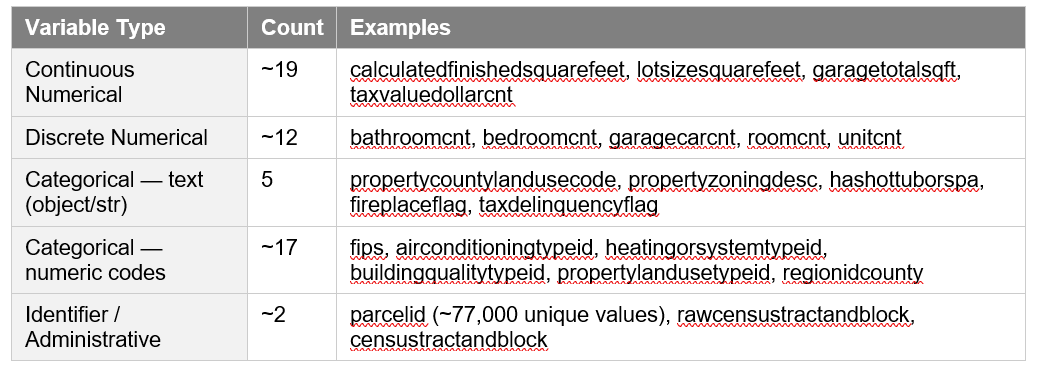
(if you have a better way of adding a table here, Im open to suggestions)

Target Variable: 
The target variable is taxvaluedollarcnt, the total assessed tax value of the property in U.S. dollars, land and structure values combined. It is continuous with 50,949 unique values and a missing rate of approximately 0.045%, making it high-quality (almost no missing values) and good for modeling. The distribution is strongly right-skewed: the median is approximately $358,878 and the mean is approximately $490,151, reflecting a small number of very high-value properties are driving the mean above the median. IQR analysis identified 5,186 outliers (6.7% of records), with an upper IQR bound of $1,112,152. This skewness was a key consideration in the feature engineering phase, where log transformations of the target and key continuous predictors were investigated as a way to stabilize variance and reduce the influence of extreme values.

Missing values and Other Important Data Issues
The raw dataset has considerable missing data. A systematic analysis grouped the 55 features into four categories by missingness level:
* Low missing (<5%): High-quality features suitable for modeling with minimal imputation - bathroomcnt (0.04%), bedroomcnt (0.04%), calculatedfinishedsquarefeet (0.30%), yearbuilt (0.39%), latitude and longitude (0.04%), and the target taxvaluedollarcnt (0.045%).
* Moderate missing (10-40%): Features still carrying signal but requiring preprocessing - lotsizesquarefeet (10.7%), unitcnt (34.7%), propertyzoningdesc (35.0%), buildingqualitytypeid (35.8%), and heatingorsystemtypeid (36.1%).
* High missing (40-90%): Features are risky, but may be useful - garagecarcnt and garagetotalsqft (67.1% each), airconditioningtypeid (67.8%), and regionidneighborhood (60.1%).
* Extremely high missing (>70%, dropped): 25 features that contain too little information, exceeding the 70% missingness threshold applied during cleaning - basementsqft (99.94%), buildingclasstypeid (99.98%), architecturalstyletypeid (99.73%), finishedsquarefeet13 (99.95%), storytypeid (99.94%), fireplaceflag (99.78%), and others.
  
Along with missing values, the EDA identified several additional data quality issues. The assessmentyear column contained a single constant value (2016) across all rows, providing no predictive information. Several identifier columns: parcelid (~77,000 unique values), rawcensustractandblock, and censustractandblock, are purely administrative and not useful for prediction. The fips column, though stored as a numeric float, is a categorical variable with only three values corresponding to the three counties. The propertyzoningdesc feature has very high cardinality (1,907 unique values), making encoding challenging. The two key continuous predictors showed notable right skew and outlier rates: calculatedfinishedsquarefeet (mean 1,785 sq ft, median 1,542 sq ft, 5.2% outliers), and lotsizesquarefeet (mean 29,973 sq ft, median 7,206 sq ft, 16.5% outliers), showing a wide range of property types across the three counties.





## 4. Methodology (What you did, and why) [20 pts]

Focus on the **process and your reasoning**, not the results.

Note: Each subsection (e.g., 4.1, 4.2, etc.) must be answered in its own Markdown cell.  Each subsection is worth 5 points. 

### 4.1 Analytical Framework

Describe your overall approach.

Include:
- your overall framework
- use of validation curves
- choice of MAE or RMSE (as appropriate) as the primary error metric

**4.1 Answer:**  

Overall Framework:
The overall framework followed a modified version of the Machine Learning Project Checklist from Hands-On Machine Learning (HOML, Appendix A), referenced in the course project. The workflow consisted of five sequential steps: (1) framing the problem and exploring the data, (2) cleaning and preprocessing, (3) investigating feature relationships and engineering, (4) model selection and baseline evaluation, and (5) hyperparameter tuning and final model selection.

Throughout all modeling stages, a consistent evaluation strategy was applied to ensure equal comparison across models and protection against overfitting. The dataset was split 80/20 into training and test sets using a fixed random seed (random_state=42), and the test set was held out completely until the final evaluation of the selected model. All model evaluation during development was conducted using Repeated K-Fold Cross-Validation with 5 folds and 5 repeats, producing 25 independent MAE scores per model. The mean and standard deviation of these scores were reported as the primary evaluation metrics.

Use of validation curves:  (NOTE - please review this section - we didnt do validation curves)
In place of formal validation curves, a parameter sweep approach was used during the hyperparameter tuning phase to serve a similar diagnostic purpose. Each hyperparameter was varied across a range of values while holding others constant, and the resulting cross-validation MAE was plotted against each parameter value. This allowed the team to identify whether a parameter was having a meaningful effect, whether the model was underfitting or overfitting at extreme values, and what the optimal range was before moving to a full grid or randomized search. While this differs from a formal validation curve in that it reports only CV MAE rather than both training and validation scores side by side, it served the practical purpose of diagnosing parameter sensitivity and guiding the subsequent tuning strategy for each model.

Mean Absolute Error (MAE) was selected as the primary error metric for the following reasons:
MAE was selected as the primary error metric in place of RMSE, which was initially identified as a candidate during the problem framing phase. While RMSE penalizes large errors more heavily, that sensitivity is a disadvantage in a dataset where 6.7% of properties exceed $1,112,152. RMSE would disproportionately weight those extreme values and give an incorrect picture of typical performance. MAE, expressed directly in U.S. dollars, provides a more honest and interpretable measure of average prediction error across the full range of properties.

The standard deviation of CV MAE served as a secondary metric for model stability. A low standard deviation indicates consistent performance across different data subsets, which provides greater confidence that the model will generalize reliably to unseen data.

Feature scaling using StandardScaler was applied to all features prior to modeling. The scaler was fitted exclusively on the training data and then applied to the test set using the same learned parameters, ensuring no information from the test set leaked into the scaling process. This step was repeated whenever new engineered features were added to the dataset.


### 4.2 Data Cleaning and Preprocessing

Describe how you prepared the data.

Include:
- issues in the raw data
- handling of missing values, outliers, inconsistencies
- key decisions and why
- what worked and what did not work

**4.2 Answer:**  
Replace this sentence with your answer.

### 4.3 Feature Engineering

Describe your feature engineering.

Include:
- transformations or new features
- why you created them
- which were useful or not useful
- what worked and what did not work

**4.3 Answer:**  
Replace this sentence with your answer.

### 4.4 Model Selection

Describe how you selected your model.

Include:
- models you tried and why
- how you evaluated generalization
- hyperparameter tuning
- how you chose the final model

**4.4 Answer:**  
Replace this sentence with your answer.

## 5. Results and Evaluation (What you found, and how well it worked) [16 pts]

Focus on **results, evidence, and interpretation**.

Note: Each subsection (e.g., 5.1, 5.2, etc.) must be answered in its own Markdown cell. 

### 5.1 Model Performance (6 points)

Briefly interpret what your metrics mean in practical terms.

Include:
- key metrics (e.g., RMSE, $R^2$)
- comparison across models
- comparison of training vs validation/test performance

**5.1 Answer:**  
Replace this sentence with your answer.

### 5.2 Visualizations (5 points)

Graphics should be made as screenshots and dragged into the Markdown cell. Do NOT add code cells to create graphics. Each visualization must be clearly labeled and explained in the text.

Include:
- relevant plots with titles and labels
- explanation of what each plot shows
- why each visualization matters

**5.2 Answer:**  
Replace this sentence with your answer. 

### 5.3 Error Analysis (5 points)

Include:
- patterns in residuals or prediction errors
- overprediction or underprediction
- outliers or unusual observations
- anything surprising or worth improving

**5.3 Answer:**  
Replace this sentence with your answer.

## 6. Conclusion [4 pts]

Summarize your findings and implications.

Include all the following:

- Clearly state your main findings and how they address your original objectives
- Highlight any business or practical implications of your findings 
- Discuss the limitations and constraints of your analysis clearly and transparently
- Suggest potential improvements or future directions
- Conclude with a final recommendation addressing the business objective

**6.1 Answer:**  
Replace this sentence with your answer.
